## Assignment 2: Linear predictors using gene expression

In [1]:
# library
import pandas as pd
import polars as pl
import numpy as np
from tqdm import tqdm
from sklearn import cluster
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os
from statsmodels.formula.api import ols, logit
import seaborn as sns

In [2]:
# functions for the assignments
def genes_variance(sample_data):
    genes_vars = {}
    for row_idx in tqdm(range(sample_data.shape[0])):
        row = brain_blood_df.row(row_idx)
        gene_ensembl_id = row[0]
        # min max of the rows
        gene_exp = row[2:]
        normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
        genes_vars[gene_ensembl_id] = np.var(row[2:])
    return genes_vars

### 0. Data Download and Preprocessing

In [3]:
data_folder = "../data"
os.makedirs(data_folder, exist_ok = True)

In [4]:
# download the data
# tpm data
tpm_url = "https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz"
tpm_file_path = "../data/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_tpm.gct.gz"
if not os.path.exists(tpm_file_path):
    tpm_cmd = f"curl --output {tpm_file_path} {tpm_url}"
    os.system(tpm_cmd)

In [5]:
# metadata
meta_url = "https://storage.googleapis.com/adult-gtex/annotations/v8/metadata-files/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
meta_file_path = "../data/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt"
if not os.path.exists(meta_file_path):
    meta_cmd = f"curl --output {meta_file_path} {meta_url}"
    os.system(meta_cmd)

In [6]:
# phenotypes
phenotype_url = "https://storage.googleapis.com/adult-gtex/annotations/v8/metadata-files/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
phenotype_file_path = "../data/GTEx_Analysis_v8_Annotations_SubjectPhenotypesDS.txt"
if not os.path.exists(phenotype_file_path):
    phenotype_cmd = f"curl --output {phenotype_file_path} {phenotype_url}"
    os.system(phenotype_cmd)

In [7]:
# load metadata files
metadata_df = pd.read_csv(
    meta_file_path, 
    sep='\t'
)
print(metadata_df[metadata_df.SAMPID == "GTEX-1117F-0003-SM-58Q7G"]['SMTS'])

0    Blood
Name: SMTS, dtype: object


In [8]:
# Load TPM data
tpm_lazy_df = pl.read_csv(
    source = tpm_file_path, 
    separator = "\t", 
    skip_rows = 2
) 

In [9]:
# phenotypes data
phenotype_df = pd.read_csv(
    phenotype_file_path, 
    sep='\t'
)
phenotype_df.head()

,SUBJID,SEX,AGE,DTHHRDY
0,GTEX-1117F,2,60-69,4.0
1,GTEX-111CU,1,50-59,0.0
2,GTEX-111FC,1,60-69,1.0
3,GTEX-111VG,1,60-69,3.0
4,GTEX-111YS,1,60-69,0.0


In [10]:
# merge metadata df + phenotypes data
metadata_df['SUBJID'] = ""
metadata_df['SUBJID'] = metadata_df['SAMPID'].apply(
    lambda x: "-".join(x.split("-")[:2])
)

metadata_df = metadata_df.merge(
    phenotype_df, 
    on = "SUBJID"
)

### 1. Multiple Linear Modeling

- Perform a multiple linear regression on the top 5K variable genes in a standardized, subsetted dataset (i.e., only blood and brain data) with tissue type as your main predictor, adjusting for age and sex.

In [11]:
# subset by blood, and brain tissues. 
brain_blood_ids = metadata_df[metadata_df.SMTS.isin(["Blood", "Brain"])].SAMPID.values
print(f"All ids for brain + blood data: {len(brain_blood_ids)}")
# add the name column; 
tpm_df_colums = np.array(tpm_lazy_df.columns)
brain_blood_ids = [ tissue_id for tissue_id in brain_blood_ids if tissue_id in tpm_df_colums]
print(f"All ids for brain + blood data: {len(brain_blood_ids)}")
brain_blood_ids.insert(0, "Name")
brain_blood_df = tpm_lazy_df.select(brain_blood_ids)

All ids for brain + blood data: 6806
All ids for brain + blood data: 3571


In [12]:
brain_blood_df

Name,GTEX-1117F-3226-SM-5N9CT,GTEX-111FC-3126-SM-5GZZ2,GTEX-111FC-3326-SM-5GZYV,GTEX-111YS-0006-SM-5NQBE,GTEX-1122O-0003-SM-5Q5DL,GTEX-1122O-0005-SM-5O99J,GTEX-1128S-0005-SM-5P9HI,GTEX-1128S-2726-SM-5H12C,GTEX-1128S-2826-SM-5N9DI,GTEX-113IC-0006-SM-5NQ9C,GTEX-113JC-0006-SM-5O997,GTEX-117XS-0005-SM-5PNU6,GTEX-117XS-3026-SM-5N9CA,GTEX-117XS-3126-SM-5GIDP,GTEX-117YW-0005-SM-5NQ8Z,GTEX-1192W-0005-SM-5NQBQ,GTEX-1192X-0005-SM-5NQC3,GTEX-1192X-0011-R10a-SM-DO941,GTEX-1192X-0011-R5a-SM-DNZZA,GTEX-1192X-0011-R6a-SM-DNZZB,GTEX-1192X-0011-R7b-SM-DNZZC,GTEX-1192X-0011-R8b-SM-DO11U,GTEX-1192X-0011-R9b-SM-DO934,GTEX-1192X-3126-SM-5N9BY,GTEX-1192X-3226-SM-5987D,GTEX-11DXW-0006-SM-5NQ7Y,GTEX-11DXW-0011-R1a-SM-DNZZD,GTEX-11DXW-0011-R3b-SM-DNZZE,GTEX-11DXW-0011-R5b-SM-DO11D,GTEX-11DXW-0011-R6a-SM-DO11N,GTEX-11DXW-0011-R7b-SM-DO119,GTEX-11DXW-1026-SM-5H11K,GTEX-11DXW-1126-SM-5H12Q,GTEX-11DXX-0005-SM-5NQ8B,GTEX-11DXY-0006-SM-5NQ8N,GTEX-11DXY-0011-R10b-SM-DO12C,…,GTEX-ZVT3-0011-R3b-SM-51MTJ,GTEX-ZVT3-0011-R5a-SM-51MSI,GTEX-ZVT3-0011-R6a-SM-51MSU,GTEX-ZVT3-0011-R7a-SM-57WCO,GTEX-ZVT3-0011-R8b-SM-57WDJ,GTEX-ZVT3-2926-SM-5GU6M,GTEX-ZVT3-3026-SM-5E43N,GTEX-ZVT4-0006-SM-57WB8,GTEX-ZVTK-0003-SM-51MRV,GTEX-ZVTK-0006-SM-57WBK,GTEX-ZVZP-0004-SM-51MS8,GTEX-ZVZP-0006-SM-51MSW,GTEX-ZVZQ-0006-SM-51MR8,GTEX-ZVZQ-0011-R10b-SM-51MRT,GTEX-ZVZQ-0011-R11a-SM-51MS6,GTEX-ZVZQ-0011-R1a-SM-57WBU,GTEX-ZVZQ-0011-R3a-SM-57WC7,GTEX-ZVZQ-0011-R4b-SM-57WCZ,GTEX-ZVZQ-0011-R5b-SM-57WDC,GTEX-ZVZQ-0011-R6b-SM-57WAY,GTEX-ZVZQ-0011-R7b-SM-57WBB,GTEX-ZVZQ-0011-R8a-SM-51MR5,GTEX-ZVZQ-0011-R9a-SM-51MRH,GTEX-ZXES-0004-SM-57WCW,GTEX-ZXES-0005-SM-57WCB,GTEX-ZXG5-0005-SM-57WCN,GTEX-ZXG5-0011-R10a-SM-57WDD,GTEX-ZXG5-0011-R5b-SM-57WBN,GTEX-ZXG5-0011-R6a-SM-57WBZ,GTEX-ZXG5-0011-R7b-SM-57WCC,GTEX-ZXG5-0011-R8a-SM-57WD1,GTEX-ZYFD-2926-SM-5GID9,GTEX-ZYFD-3026-SM-5E44C,GTEX-ZYY3-3026-SM-5GIEJ,GTEX-ZYY3-3126-SM-5SI9L,GTEX-ZZPT-2926-SM-5EQ5S,GTEX-ZZPT-3026-SM-5GZXH
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ENSG0000022397…",0.01776,0.0,0.0,0.02171,0.0,0.03015,0.0203,0.01709,0.0,0.1675,0.02104,0.02537,0.0,0.03692,0.02492,0.06809,0.0,0.03947,0.0,0.0,0.0,0.0,0.0,0.02598,0.03228,0.02443,0.0,0.0,0.0,0.01051,0.0,0.0,0.0,0.1421,0.02459,0.0,…,0.01302,0.0,0.0,0.01167,0.0,0.0,0.03554,0.04858,0.0,0.1145,0.0,0.02417,0.0,0.01716,0.05961,0.01952,0.0,0.0,0.03255,0.0,0.0,0.0,0.0,0.0,0.02128,0.0,0.0,0.01316,0.01139,0.0,0.006319,0.0,0.0,0.02613,0.0,0.03126,0.01874
"""ENSG0000022723…",6.892,4.225,7.778,1.555,1.53,2.747,4.441,2.359,8.939,10.47,1.287,3.138,3.693,8.219,4.217,2.098,0.3579,1.542,2.137,1.918,1.893,2.037,3.6,5.04,6.347,4.262,0.773,0.8928,0.8156,2.531,0.8327,5.393,2.201,2.529,2.882,2.61,…,1.187,1.003,1.099,0.456,1.155,7.012,1.874,3.194,1.41,2.906,2.121,3.43,4.169,1.899,5.174,1.245,2.536,1.496,1.864,1.79,3.14,1.48,2.73,1.405,2.743,6.072,1.124,1.936,1.721,0.9683,1.308,5.791,2.314,5.511,4.305,3.907,2.123
"""ENSG0000027826…",0.0,0.4912,0.771,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6112,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""ENSG0000024348…",0.0,0.07713,0.0,0.0,0.0,0.0,0.0,0.03413,0.0,0.0,0.0,0.0,0.03078,0.0,0.0,0.04532,0.0,0.0394,0.05749,0.05448,0.1037,0.03633,0.0,0.05187,0.1289,0.0,0.02522,0.0,0.04313,0.02098,0.1256,0.06669,0.0,0.0,0.0,0.0,…,0.052,0.0,0.02717,0.0,0.1969,0.0,0.0,0.09698,0.0,0.1143,0.0,0.0,0.0,0.06851,0.03967,0.03897,0.0405,0.0,0.03249,0.04288,0.0,0.0255,0.07683,0.0,0.0,0.0,0.03592,0.0,0.09099,0.0,0.02523,0.07462,0.03735,0.1043,0.04682,0.0,0.0
"""ENSG0000023761…",0.0,0.0,0.0,0.0,0.0,0.0,0.0576,0.02424,0.0,0.0,0.0,0.0,0.02186,0.0,0.0,0.0,0.

In [13]:
# Use the bulk tissue expression file to select the top 5,000 most variable genes.'
genes_vars = {}
for row_idx in tqdm(range(brain_blood_df.shape[0])):
    row = brain_blood_df.row(row_idx)
    gene_ensembl_id = row[0]
    # min max of the rows
    gene_exp = row[2:]
    normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
    genes_vars[gene_ensembl_id] = np.var(row[2:])


  0%|                                                                                                                                                                                                                   | 0/56200 [00:00<?, ?it/s]/var/folders/rd/c2tlh0qn3y7fvt1bwwd_d2x80000gn/T/ipykernel_7628/3523738767.py:8: RuntimeWarning: invalid value encountered in divide
  normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56200/56200 [01:13<00:00, 762.26it/s]


In [13]:
# get the top 5,000 most variable genes
from operator import itemgetter
topk = 5000
topk_genes = sorted(genes_vars.items(), key=itemgetter(1), reverse=True)[:topk]
most_variables_genes = [k[0] for k in topk_genes]
print(most_variables_genes[:10])

['ENSG00000244734.3', 'ENSG00000188536.12', 'ENSG00000210082.2', 'ENSG00000198804.2', 'ENSG00000198712.1', 'ENSG00000198938.2', 'ENSG00000198899.2', 'ENSG00000163220.10', 'ENSG00000198886.2', 'ENSG00000198763.3']


In [14]:
# subset the data by most variables genes
prepped_data = brain_blood_df.filter(
    pl.col('Name').is_in(most_variables_genes)
).to_pandas()
prepped_data = prepped_data.reset_index(drop=True).set_index("Name").T

prepped_data = prepped_data.reset_index().merge(
    metadata_df[['SAMPID', 'SMTS', 'SEX', 'AGE']], 
    left_on = "index", 
    right_on = "SAMPID"
).drop(['index', 'SAMPID'], axis = 1)
prepped_data['tissue'] = prepped_data.SMTS
prepped_data.drop(columns = ['SMTS'], axis = 1, inplace = True)
prepped_data.head()

,ENSG00000268903.1,ENSG00000269981.1,ENSG00000225972.1,ENSG00000225630.1,ENSG00000237973.1,ENSG00000229344.1,ENSG00000240409.1,ENSG00000248527.1,ENSG00000198744.5,ENSG00000188976.10,...,ENSG00000210191.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2,ENSG00000210195.2,ENSG00000210196.2,SEX,AGE,tissue
0,4.190,1.947,19.980,1275.00,136.700,17.160,30.900,7976.0,31.610,32.60,...,5.624,8380.0,7000.0,25.820,31410.0,5.584,5.4200,2,60-69,Brain
1,1.946,2.822,11.220,1408.00,111.300,42.700,38.170,5852.0,56.890,47.77,...,4.704,7620.0,6380.0,21.780,32050.0,2.530,5.8940,1,60-69,Brain
2,5.278,2.769,16.070,801.80,48.790,24.140,39.080,4863.0,26.500,74.71,...,2.215,6256.0,6063.0,19.000,30980.0,3.178,2.3130,1,60-69,Brain
3,181.100,354.600,4.542,54.19,9.244,4.789,3.265,518.4,5.157,17.11,...,0.000,1067.0,1972.0,6.529,3069.0,0.000,0.0000,1,60-69,Blood
4,4.379,13.100,4.166,209.00,50.920,13.940,16.900,2103.0,16.900,106.40,...,2.425,6048.0,6354.0,23.950,8713.0,4.696,0.5064,2,60-69,Blood


In [15]:
# Standardize Female + Meb
sex_maps = {"1": "M" ,"2": "F"}
prepped_data['SEX'] = prepped_data['SEX'].apply(
    lambda x: sex_maps.get(str(x))
)
prepped_data['SEX'].value_counts()

SEX
M    2527
F    1044
Name: count, dtype: int64

- Multiple Linear modelling


        Main predictor: tissue
  
        Adjusted predictors: age, sex
  
        y: respective gene expression

In [16]:
# standardize the data
X_data = prepped_data.drop(columns=["SEX", "AGE", "tissue"])
genes_columns = X_data.columns.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# standardize AGE
#standardized_age = scaler.fit_transform(prepped_data[['AGE']]).flatten()

predictors_df = pd.DataFrame([
    pd.Categorical(prepped_data.tissue),
    pd.Categorical(prepped_data.AGE), 
    pd.Categorical(prepped_data.SEX)
]).T
predictors_df.columns = ['tissue', 'age', 'sex']

# Logistic regression with first standardized genes
genes_effect_size = {}
significant_gene_expr = {}
for gene_idx, gene in tqdm(enumerate(genes_columns)):
    df = pd.concat([pd.DataFrame({"y":X_scaled[:, gene_idx]}), predictors_df], axis = 1)
    linear_model = ols(
        "y~tissue + age + sex", 
        data = df
    ).fit()
    
    # add F-statistic of the fully specified model
    significant_gene_expr[gene] = linear_model.fvalue

    # add the effect size of tissue type
    tissue_idx = np.where(np.array(linear_model.params.index) == "tissue[T.Brain]")[0][0]
    genes_effect_size[gene] = list(linear_model.params)[tissue_idx]

5000it [03:06, 26.85it/s]


In [20]:
# top 5 significant results; 
top5_significant_results = sorted(significant_gene_expr.items(), key=itemgetter(1), reverse=True)[:5]
for gene, f_value in top5_significant_results:
    gene_idx = np.where(genes_columns == gene)[0][0]
    print(f"Gene idx: {gene_idx} gene {gene} F-value: {f_value}")
    df = pd.concat([pd.DataFrame({"y":X_scaled[:, gene_idx]}), predictors_df], axis = 1)
    linear_model = ols(
        "y~tissue + age + sex", 
        data = df
    ).fit()
    print(linear_model.summary())

Gene idx: 4310 gene ENSG00000104894.11 F-value: 2011.9265028151508
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     2012.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:34:29   Log-Likelihood:                -2210.3
No. Observations:                3571   AIC:                             4437.
Df Residuals:                    3563   BIC:                             4486.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

Text(0.5, 0, 'tissue[T.Brain] coefficient')

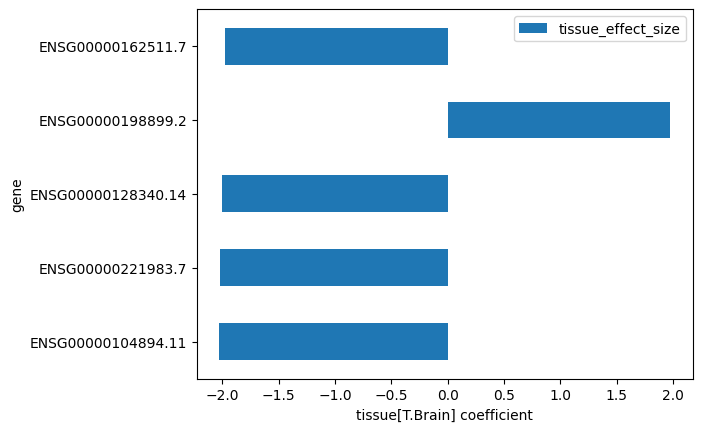

In [21]:
# top five largest effect sizes
top5_largest_effect_size = sorted(genes_effect_size.items(), key=lambda item: abs(item[1]), reverse=True)[:5]
top5_largest_effect_size_df = pd.DataFrame(top5_largest_effect_size)
top5_largest_effect_size_df.columns = ['gene', 'tissue_effect_size']

# bar plot
top5_largest_effect_size_df
top5_largest_effect_size_df.plot.barh(
    x = "gene", 
    y = "tissue_effect_size"
)
plt.xlabel("tissue[T.Brain] coefficient")

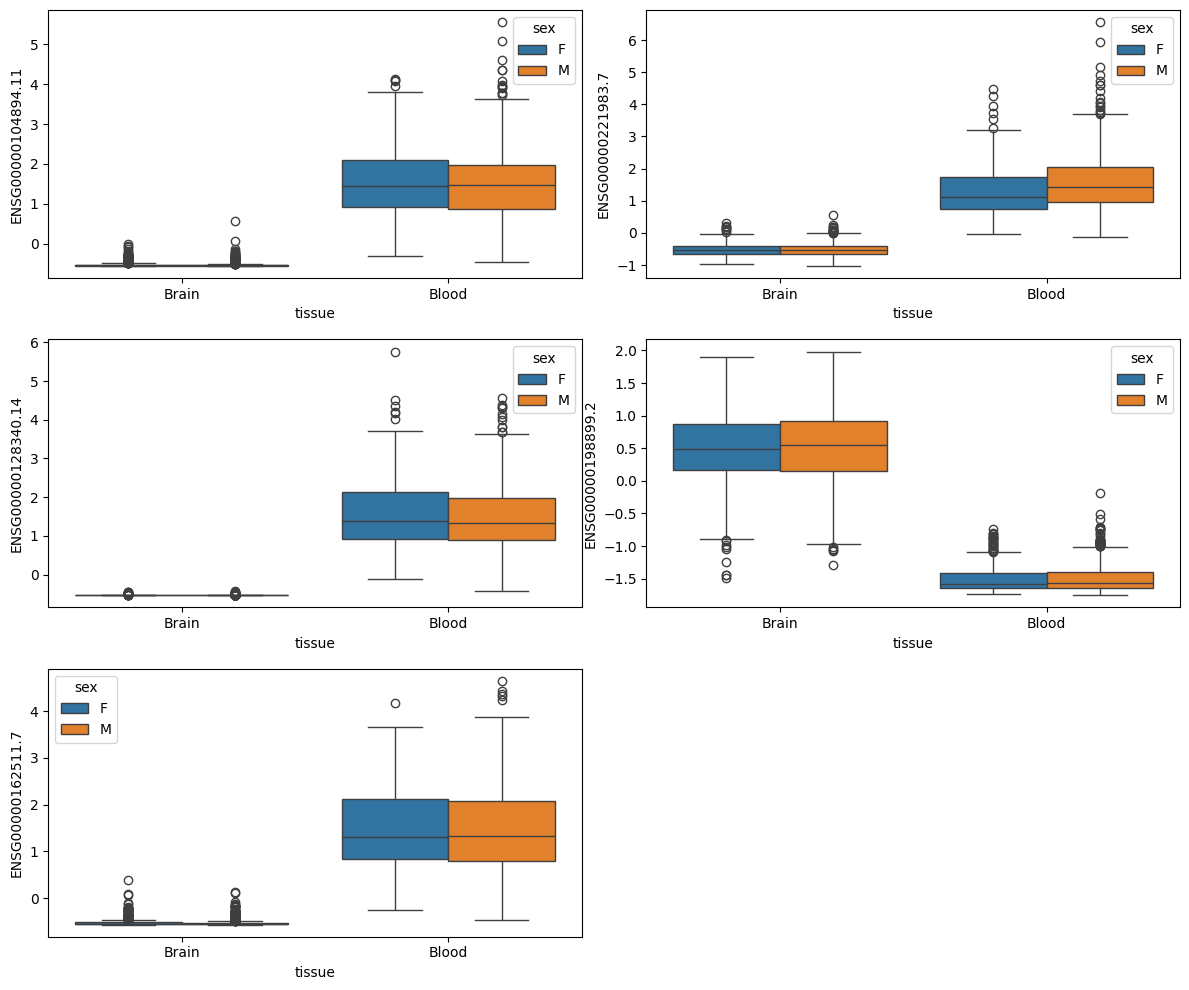

In [24]:
# plot the results of the largest effects size of tissue[T.brain], by tissue, and colored by sex
fig, axs = plt.subplots(nrows = 3, ncols = 2, figsize=(12, 10))
for ax, (gene, _) in zip(axs.flatten()[:5], top5_largest_effect_size):
    # gene idx
    gene_idx = np.where(genes_columns == gene)[0][0]
    #df = pd.concat([pd.DataFrame({ gene :prepped_data[[gene]].values.flatten()}), predictors_df], axis = 1)
    df = pd.concat([
        pd.DataFrame({ gene :X_scaled[:, gene_idx]}), 
        predictors_df
    ], axis = 1)
    sns.boxplot(
        data = df, 
        y = gene, 
        x = 'tissue', 
        ax = ax, 
        hue = "sex", 
        legend = True
    )
fig.delaxes(axs.flatten()[5])
plt.tight_layout()

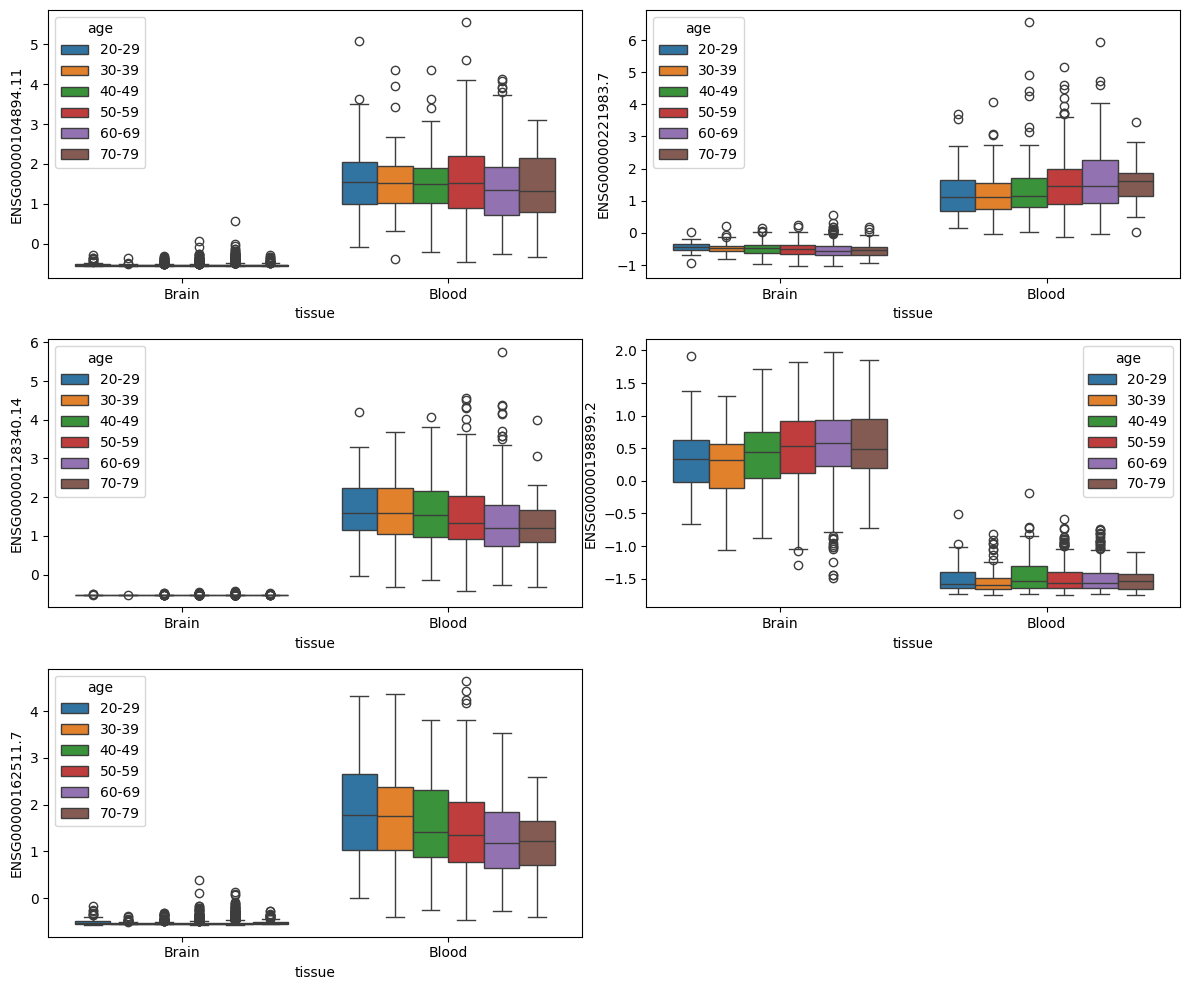

In [25]:
# plot the results of the largest effects size by age, and color by tissues
age_order = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
fig, axs = plt.subplots(nrows = 3, ncols = 2, figsize=(12, 10))
for ax, (gene, _) in zip(axs.flatten()[:5], top5_largest_effect_size):
    # gene idx
    gene_idx = np.where(genes_columns == gene)[0][0]
    #df = pd.concat([pd.DataFrame({ gene :prepped_data[[gene]].values.flatten()}), predictors_df], axis = 1)
    df = pd.concat([
        pd.DataFrame({ gene :X_scaled[:, gene_idx]}), 
        predictors_df
    ], axis = 1)
    sns.boxplot(
        data = df, 
        y = gene, 
        x = 'tissue', 
        ax = ax, 
        hue='age',
        hue_order=age_order,
        legend = True
    )
fig.delaxes(axs.flatten()[5])
plt.tight_layout()

In [26]:
np.sort(np.array([ 
    gene for gene, _ in top5_largest_effect_size]
)) == np.sort(np.array([ gene for gene, _ in top5_significant_results]))

array([ True,  True,  True,  True,  True])

## Multiple Linear modelling results interpretation

__Choosing top significant results__

I used the F-value to pick the top five significant results. In this case, a higher F-value represents a stronger model fit. From see that expression from genes `ENSG00000104894.11`, `ENSG00000128340.14`, `ENSG00000162511.7`, `ENSG00000198899.2`, and `ENSG00000221983.7` are the top five significant features.



__Larget effect size__

All the top-picked significant gene expressions were the same as those picked for the gene with the largest effect size for the tissue coefficient. Among the selected genes, 4 showed negative effect sizes, and 1 showed a positive effect size at the `tissue[T.brain]` coefficient. This trend is further supported by the data, which show that expression of the four genes was lower in the brain than in blood tissues. 

One of the gene that `tissue[T.brain]` was positive is the gene; `ENSG00000198899.2` based on ensembl.org, its name is `MT-ATP6` whose roles are as follows based on `https://www.genecards.org/`most involved in proton channel activity, as listed below. 

    1. Enables proton channel activity. 
    2. Contributes to proton-transporting ATP synthase activity, rotational mechanism. 
    3. Involved in proton motive force-driven mitochondrial ATP synthesis and proton transmembrane transport. 

Additionally, the gene is implicated in neurodegenerative disease examples: NARP syndrome, Parkinson's disease, multiple sclerosis, and systemic lupus erythematosus. Thus it will make sense why its coefficient `tissue[T.brain]`, and thus the gene expression higher in brain as compared to blood. 


In terms of effects of sex, in general, we see the same trend of gene expression across sex, but with slight variation in the distributions per male or female, which can be explained by the small effect size of `sex[T.M]` throughout the top significant results, ranging from (`-0.0210` to `0.0813`).


In terms of the age-group, based on data distribution, we can see apparent differences in gene expression pattern, especially if you consider comparing between younger vs older patients. An example in gene `ENSG00000162511.7` we can see a gradual decline in the gene expression levels from younger to older patients.



## 2. Logistic Regression

- We are interested in determining if gene expression from blood can predict sex. 
- Perform a logistic regression on the top 5K variable genes in blood samples only, using sex as your main outcome and gene expression in blood as your main predictor.

In [14]:
# get blood samples
blood_ids = metadata_df[metadata_df.SMTS.isin(["Blood"])].SAMPID.values
print(f"All ids for blood data: {len(blood_ids)}")
# add the name column; 
tpm_df_colums = np.array(tpm_lazy_df.columns)
blood_ids = [ tissue_id for tissue_id in blood_ids if tissue_id in tpm_df_colums]
print(f"All ids for blood data: {len(blood_ids)}")
blood_ids.insert(0, "Name")
blood_df = tpm_lazy_df.select(blood_ids)

All ids for blood data: 3480
All ids for blood data: 929


In [44]:
# get top k variable genes
topk = 5000
blood_gene_variances = genes_variance(blood_df)
top_var_genes = sorted(blood_gene_variances.items(), key=lambda item: item[1], reverse=True)[:topk]
most_variables_genes = [k[0] for k in top_var_genes]
# subset the data by most variables genes
prepped_data = blood_df.filter(
    pl.col('Name').is_in(most_variables_genes)
).to_pandas()

prepped_data = prepped_data.reset_index(drop=True).set_index("Name").T
prepped_data = prepped_data.reset_index().merge(
    metadata_df[['SAMPID', 'SEX']], 
    left_on = "index", 
    right_on = "SAMPID"
).drop(['index', 'SAMPID'], axis = 1)
prepped_data.head()

  0%|                                                                                                                                                                                                          | 34/56200 [00:01<35:41, 26.22it/s]/var/folders/rd/c2tlh0qn3y7fvt1bwwd_d2x80000gn/T/ipykernel_7628/1798594136.py:9: RuntimeWarning: invalid value encountered in divide
  normalized_gene_exp = (gene_exp - np.min(gene_exp)) / (np.max(gene_exp) - np.min(gene_exp))
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56200/56200 [01:07<00:00, 834.04it/s]


,ENSG00000268903.1,ENSG00000269981.1,ENSG00000225972.1,ENSG00000225630.1,ENSG00000237973.1,ENSG00000229344.1,ENSG00000240409.1,ENSG00000248527.1,ENSG00000198744.5,ENSG00000188976.10,...,ENSG00000210176.1,ENSG00000210184.1,ENSG00000210191.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2,ENSG00000210195.2,ENSG00000210196.2,SEX
0,181.100,354.60,4.542,54.19,9.244,4.789,3.265,518.4,5.157,17.11,...,0.5441,0.0000,0.0000,1067.0,1972.0,6.529,3069.0,0.000,0.0000,1
1,4.379,13.10,4.166,209.00,50.920,13.940,16.900,2103.0,16.900,106.40,...,0.4991,0.5836,2.4250,6048.0,6354.0,23.950,8713.0,4.696,0.5064,2
2,262.100,373.30,4.203,64.75,12.550,6.496,5.180,420.5,8.114,13.34,...,0.0000,0.8834,0.7341,901.0,1148.0,3.777,2477.0,0.000,0.0000,2
3,311.800,560.10,1.321,34.50,15.690,2.368,1.090,663.4,1.672,19.97,...,0.0000,1.1900,0.0000,1359.0,2575.0,18.320,2089.0,0.000,0.0000,2
4,40.340,66.06,289.500,47.37,170.900,2.887,2.518,558.3,2.227,41.10,...,0.0000,0.0000,0.0000,765.9,1333.0,9.232,1859.0,0.000,0.0000,1


In [45]:
# predictors
predictors_df = pd.DataFrame([
    pd.Categorical(prepped_data.SEX)
]).T

# binarize sex
prepped_data['SEX'] = prepped_data['SEX'].apply( lambda x: x - 1 )

In [47]:
# Define X, and y matrices
X = prepped_data.drop(columns = ['SEX'])
y = prepped_data['SEX']

# standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# data
X_ = pd.DataFrame(X_scaled)
X_.columns = prepped_data.drop(columns = ['SEX']).columns.tolist()
print(X_.shape)

(929, 5000)


In [53]:
# Logistic Regression to get top 5 significant results + top 5 effect size
import statsmodels.api as sm
llr_pvalue = {}
effect_size = {}
for gene in tqdm(X_.columns.values):
    try:
        logit_model = sm.Logit(y, sm.add_constant(X_[gene])).fit(disp=0)
        # get model llr pvalue
        if logit_model.mle_retvals.get("converged"):
            # llr pvalue
            llr_pvalue[gene] = logit_model.llr_pvalue
            # effect size
            effect_size[gene] = logit_model.params.values[1]
    except Exception:
        continue

 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 4962/5000 [00:23<00:00, 236.44it/s]/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████

In [58]:
# top 5 significant results; 
top5_significant_results = sorted(llr_pvalue.items(), key= lambda x: x[1], reverse=False)[:5]
top5_significant_results

[('ENSG00000067048.16', 1.0230990031021289e-251),
 ('ENSG00000229807.10', 2.565237150075942e-240),
 ('ENSG00000126012.11', 2.0883143845793032e-17),
 ('ENSG00000198034.10', 1.7679874206316816e-12),
 ('ENSG00000215301.9', 1.69024550411135e-11)]

<Axes: ylabel='gene'>

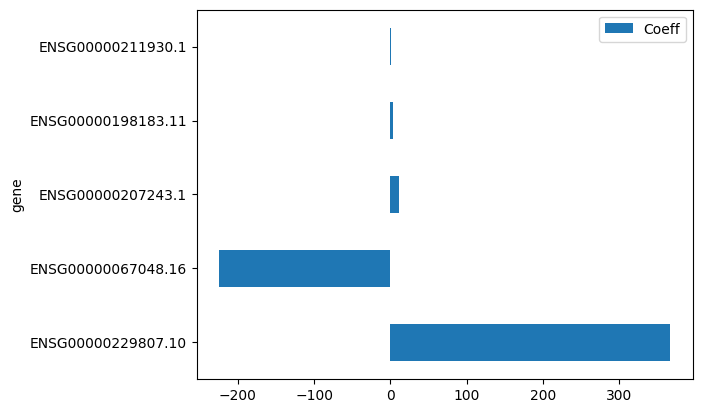

In [57]:
# top five largest effect sizes
top5_largest_effect_size = sorted(effect_size.items(), key=lambda item: abs(item[1]), reverse=True)[:5]
top5_largest_effect_size_df = pd.DataFrame(top5_largest_effect_size)
top5_largest_effect_size_df.columns = ['gene', 'Coeff']

# bar plot
top5_largest_effect_size_df.plot.barh(
    x = "gene", 
    y = "Coeff"
)

In [62]:
top5results = np.array([ gene for gene, _ in top5_significant_results])
i = 0
for gene, _ in top5_largest_effect_size:
    if gene in top5results:
        i += 1
print(i)

2


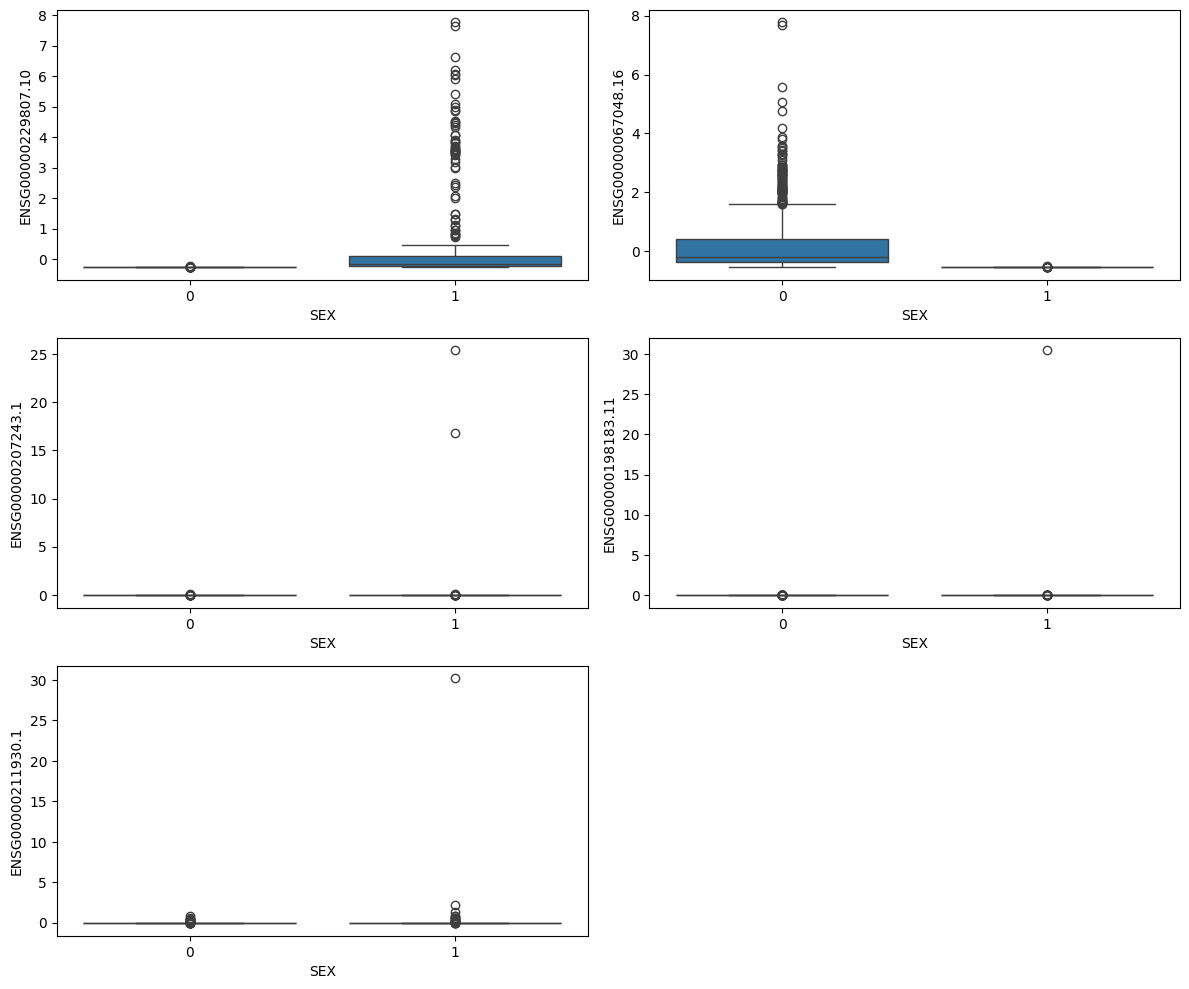

In [87]:
fig, axs = plt.subplots(nrows = 3, ncols = 2, figsize=(12, 10))
for ax, (gene, _) in zip(axs.flatten()[:5], top5_largest_effect_size):
    sns.boxplot(
        y = X_[gene], 
        x = y, 
        ax = ax,
        legend = True
    )
fig.delaxes(axs.flatten()[5])
plt.tight_layout()

### Logistic Regression Results Interpretation

I selected the top five based on the LLR p-value and used p < 0.05 to assess effect size. There are only two genes common to both the top significant and the top largest-effect-size lists.

For the top genes with largest effect size; three of the genes were linked to X or Y chromosome, as shown below. 

    - ENSG00000229807: related to X chromosome
    - ENSG00000067048: Y-linked 
    - ENSG00000207243: Y-RNA

In terms of data distributions, I didn't see much difference across the groups when I plotted the gene expression by sex, as compare to what I saw in the linear regression models. 